<a href="https://colab.research.google.com/github/vipinkumarcp/Deep_Learning/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install tensorflow

In [3]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
print(tf.__version__)

2.19.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [12]:
dataset = pd.read_csv('Churn_Modelling.csv')

In [14]:
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
## divide the dataset intgo indepent and depent features

In [19]:
X = dataset.iloc[:,3:13]
y = dataset.iloc[:,13]

In [17]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [20]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


In [26]:
#feature engineering --handling caterogycal features
gerography = pd.get_dummies(X['Geography'],dtype=int,drop_first=True)
gender = pd.get_dummies(X['Gender'],dtype=int,drop_first=True)


In [27]:
#concate varibles with dataset

In [28]:
X.drop(['Geography','Gender'],axis=1,inplace=True)

In [30]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [33]:
X= pd.concat([X,gerography,gender],axis=1)

In [34]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0


In [35]:
#splitting the dataset with traing ste and test set

In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)


In [38]:
#features scalling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [40]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [41]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [44]:
X_train.shape

(8000, 11)

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [47]:
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU
from tensorflow.keras.layers import Dropout


In [48]:
#intilization ANN

In [51]:
classifier = Sequential()


In [52]:
#add input layer  ..relu get applied in next layer
classifier.add(Dense(units=11,activation='relu'))

In [53]:
#adding first hidden layer

In [54]:
classifier.add(Dense(units=7,activation='relu'))

In [55]:
classifier.add(Dense(units=6,activation='relu'))

In [57]:
#adding outputlayer
classifier.add(Dense(1,activation='sigmoid'))

In [64]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [68]:
##early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)

In [69]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8698 - loss: 0.3155 - val_accuracy: 0.8470 - val_loss: 0.3711
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8668 - loss: 0.3150 - val_accuracy: 0.8466 - val_loss: 0.3721
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8679 - loss: 0.3140 - val_accuracy: 0.8485 - val_loss: 0.3726
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8696 - loss: 0.3134 - val_accuracy: 0.8463 - val_loss: 0.3744
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8699 - loss: 0.3137 - val_accuracy: 0.8501 - val_loss: 0.3683
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8698 - loss: 0.3135 - val_accuracy: 0.8501 - val_loss: 0.3696
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8711 - loss: 0.3128 - val_accuracy: 0.8497 - val_loss: 0.3707
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8718 - loss: 0.3136 - 

In [70]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

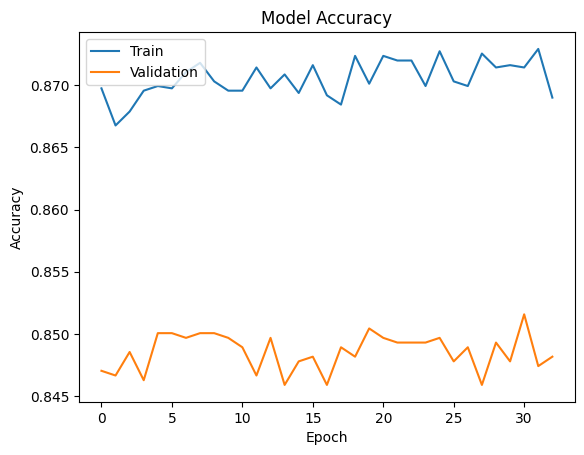

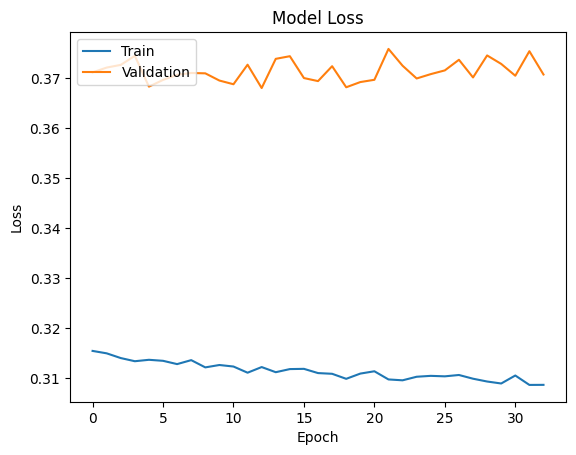

In [71]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [72]:
#prediction and evaluation of model

In [73]:
#predicting the test set results

In [74]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [75]:
#make the confusion matrix

In [76]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

In [77]:
cm

array([[1499,   96],
       [ 193,  212]])

In [78]:
#CALCUALTE THE ACCURCY

In [79]:
from sklearn.metrics import accuracy_score

In [81]:
score = accuracy_score(y_pred,y_test)

In [82]:
score

0.8555

In [83]:
#get the weights

In [84]:
classifier.get_weights()

[array([[ 5.6848549e-03, -2.2137512e-02,  1.9192064e-01, -4.5142598e-02,
          7.1771011e-02, -5.3369358e-02, -9.4474256e-02, -1.3219853e-01,
         -1.9492795e-01, -4.1022253e-01,  6.3495159e-02],
        [ 7.4625254e-02, -9.6658006e-02, -2.2956079e-01, -5.6025933e-02,
         -1.1367391e+00,  1.0360097e-01, -8.3763677e-01,  7.9275435e-01,
         -1.2867901e+00, -2.2834401e-01, -8.1127334e-01],
        [ 1.0152728e-02, -1.6274925e-01,  1.8711972e-01,  6.5233603e-02,
          1.9695055e-01,  1.5946180e-01, -5.6331750e-02,  4.8742303e-01,
          3.0087686e-01,  4.4251055e-01,  6.8894967e-02],
        [ 1.1335124e-01, -7.0429045e-01, -9.6281219e-01, -2.4934401e-01,
         -1.5522160e-01,  2.0196292e-01, -1.0792988e-01, -2.4580412e-01,
          2.0583335e-01, -3.4332341e-01, -4.4867259e-02],
        [-5.4972029e-01, -2.6364323e-01, -2.7991533e-01, -9.2878515e-01,
          3.2194105e-01,  1.2969662e+00,  1.6973853e-01, -9.9299918e-04,
          3.3674917e-01, -4.0862113e-0